# 02. KIỂM TRA CHẤT LƯỢNG DỮ LIỆU (DATA QUALITY CHECK)

## MỤC LỤC
1. [Import thư viện & Đọc dữ liệu](#1-import-thư-viện--đọc-dữ-liệu)
2. [Missing Data (Dữ liệu bị thiếu)](#2-missing-data-dữ-liệu-bị-thiếu)
   - 2.1. Thống kê số lượng và tỷ lệ khuyết thiếu
   - 2.2. Đánh giá & Định hướng xử lý (Markdown)
3. [Kiểm tra tính nhất quán & vô lý của dữ liệu (Data Integrity Check)](#3-kiểm-tra-tính-nhất-quán--vô-lý-của-dữ-liệu-data-integrity-check)
   - 3.1. Kiểm tra trùng lặp sinh viên (`student_id`)
   - 3.2. Kiểm tra ngày nộp bài trong `studentAssessment` (`date_submitted`)
   - 3.3. Kiểm tra tương tác VLE không hợp lệ (`sum_click <= 0`)
4. [Outliers (Giá trị bất thường)](#4-outliers-giá-trị-bất-thường)
   - 4.1. Kiểm tra điểm số và tương tác bất thường
   - 4.2. Trực quan hóa Outliers bằng Boxplot
   - 4.3. Đánh giá & Định hướng xử lý (Markdown)
5. [Data Imbalance (Mất cân bằng dữ liệu)](#5-data-imbalance-mất-cân-bằng-dữ-liệu)
   - 5.1. Phân tích phân bố biến mục tiêu `final_result`
   - 5.2. Trực quan hóa tỷ lệ các lớp dữ liệu
   - 5.3. Đánh giá ảnh hưởng tới mô hình Machine Learning (Markdown)
6. [Tổng kết & Đánh giá tác động đến mô hình Machine Learning](#6-tổng-kết--đánh-giá-tác-động-đến-mô-hình-machine-learning)
---

## 1. Import thư viện & Đọc dữ liệu

In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

In [2]:
assessments = pd.read_csv('data/assessments.csv')
courses = pd.read_csv('data/courses.csv')
student_assessment = pd.read_csv('data/studentAssessment.csv')
student_info = pd.read_csv('data/studentInfo.csv')
student_registration = pd.read_csv('data/studentRegistration.csv')
student_vle = pd.read_csv('data/studentVle.csv')
vle = pd.read_csv('data/vle.csv')

## 2. Missing Data (Dữ liệu bị thiếu)

### 2.1. Thống kê số lượng và tỷ lệ khuyết thiếu

In [4]:
# Hàm thống kê dữ liệu khuyết thiếu cho từng DataFrame
def check_missing(df, df_name):
    missing_count = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df)) * 100
    df_missing = pd.DataFrame({
        'Tên bảng': df_name,
        'Cột': missing_count.index,
        'Số lượng thiếu': missing_count.values,
        'Tỷ lệ (%)': missing_pct.round(2).values
    })
    return df_missing[df_missing['Số lượng thiếu'] > 0]

# Thống kê trên các bảng chính
missing_summary = pd.concat([
    check_missing(student_info, 'studentInfo'),
    check_missing(student_registration, 'studentRegistration'),
    check_missing(assessments, 'assessments'),
    check_missing(student_assessment, 'studentAssessment')
], ignore_index=True)

missing_summary.sort_values(by='Tỷ lệ (%)', ascending=False)

,Tên bảng,Cột,Số lượng thiếu,Tỷ lệ (%)
2,studentRegistration,date_unregistration,22521,69.10
3,assessments,date,11,5.34
0,studentInfo,imd_band,1111,3.41
1,studentRegistration,date_registration,45,0.14
4,studentAssessment,score,173,0.10


### 2.2. Đánh giá & Nhận xét về Dữ liệu Khuyết thiếu (Missing Data)

| Bảng dữ liệu | Tên cột bị thiếu | Ý nghĩa dữ liệu thiếu | Phương án xử lý đề xuất |
| :--- | :--- | :--- | :--- |
| `studentRegistration` | `date_unregistration` | Sinh viên **hoàn thành khóa học** (không hủy đăng ký). | **Giữ nguyên NaN**, vì thiếu dữ liệu ở đây mang ý nghĩa logic (sinh viên không bỏ học). |
| `studentInfo` | `imd_band` | Thiếu thông tin chỉ số hộ gia đình/khu vực sinh sống. | Điền giá trị xuất hiện nhiều nhất (**Mode**) hoặc gắn nhãn `'Unknown'`. |
| `assessments` | `date` | Một số bài thi (đặc biệt là bài thi cuối kỳ `Exam`) không có ngày nộp cố định. | Bổ sung theo mốc thời gian kết thúc môn học (ví dụ: ngày 240/261) hoặc dùng median. |
| `studentAssessment` | `score` | Sinh viên bỏ thi/không nộp bài đánh giá. | Điền bằng `0` điểm cho các bài bỏ nộp. |

## 3. Kiểm tra tính nhất quán & vô lý của dữ liệu (Data Integrity Check)

### 3.1. Kiểm tra các giá trị trùng lặp của `student_id`

Mỗi sinh viên (`id_student`) có thể đăng ký nhiều môn học (`code_module`) hoặc học lại qua các kỳ học khác nhau (`code_presentation`). Cần kiểm tra trùng lặp trên cả cấp độ bảng sinh viên và cấp độ đăng ký khóa học.

In [12]:
# 1. Kiểm tra trùng lặp id_student đơn thuần trong bảng studentInfo
duplicate_students = student_info[student_info.duplicated(subset=['id_student'], keep=False)]
print(f"Số bản ghi id_student xuất hiện nhiều hơn 1 lần trong studentInfo: {len(duplicate_students)}")
print(f"Số sinh viên duy nhất trùng lặp: {student_info['id_student'].duplicated().sum()}")

# 2. Kiểm tra trùng lặp cặp (id_student, code_module, code_presentation) trong studentInfo
dup_registration = student_info[student_info.duplicated(subset=['id_student', 'code_module', 'code_presentation'], keep=False)]
print(f"Số bản ghi trùng lặp hoàn toàn khóa học & kỳ học: {len(dup_registration)}")

# Hiển thị ví dụ sinh viên đăng ký nhiều học kỳ/khóa học
student_info[student_info['id_student'].isin(duplicate_students['id_student'].head(2))][['id_student', 'code_module', 'code_presentation', 'final_result']]

Số bản ghi id_student xuất hiện nhiều hơn 1 lần trong studentInfo: 7346
Số sinh viên duy nhất trùng lặp: 3808
Số bản ghi trùng lặp hoàn toàn khóa học & kỳ học: 0


,id_student,code_module,code_presentation,final_result
15,65002,AAA,2013J,Withdrawn
22,94961,AAA,2013J,Withdrawn
395,65002,AAA,2014J,Fail
403,94961,AAA,2014J,Pass


> **Phân tích nghiệp vụ về trùng lặp `id_student`:**
> - `id_student` trùng lặp trong `studentInfo` **không phải lỗi dữ liệu**. 
> - Nguyên nhân do một sinh viên có thể đăng ký nhiều môn học (`code_module`) khác nhau hoặc học lại một môn ở nhiều học kỳ (`code_presentation`) khác nhau.
> - **Khắc phục khi Feature Engineering:** Định danh duy nhất một lượt đăng ký học của sinh viên bằng khóa phức hợp: `(id_student, code_module, code_presentation)`.

### 3.2. Kiểm tra ngày nộp bài âm/dương trong `studentAssessment` (`date_submitted`)

Trường `date_submitted` thể hiện thời điểm sinh viên nộp bài so với ngày bắt đầu khóa học.

In [13]:
# Thống kê số lượng bài nộp trước hạn (date_submitted < 0) và nộp sau/đúng hạn (date_submitted >= 0)
early_submissions = student_assessment[student_assessment['date_submitted'] < 0]
late_or_ontime_submissions = student_assessment[student_assessment['date_submitted'] >= 0]

print(f"Tổng số bản ghi trong studentAssessment: {len(student_assessment)}")
print(f"Số lượt nộp bài có date_submitted < 0 (Nộp trước khi khóa học bắt đầu): {len(early_submissions)} ({len(early_submissions)/len(student_assessment)*100:.2f}%)")
print(f"Giá trị date_submitted nhỏ nhất: {student_assessment['date_submitted'].min()}")
print(f"Giá trị date_submitted lớn nhất: {student_assessment['date_submitted'].max()}")

Tổng số bản ghi trong studentAssessment: 173912
Số lượt nộp bài có date_submitted < 0 (Nộp trước khi khóa học bắt đầu): 2057 (1.18%)
Giá trị date_submitted nhỏ nhất: -11
Giá trị date_submitted lớn nhất: 608


> **Giải thích ý nghĩa nghiệp vụ của `date_submitted < 0`:**
> - `date_submitted = 0` tương ứng với ngày khóa học chính thức bắt đầu (Course Start Date).
> - **`date_submitted < 0`** có nghĩa là sinh viên đã hoàn thành và nộp bài đánh giá **trước khi khóa học chính thức bắt đầu** (ví dụ: các bài tự đánh giá, bài khảo sát đầu khóa, hoặc sinh viên tiếp cận hệ thống và làm bài sớm).
> - **Kết luận:** Đây là dữ liệu hợp lệ về mặt hệ thống, phản ánh mức độ chủ động cao của sinh viên. Do đó, **giữ nguyên dữ liệu này** và có thể khai thác thuộc tính nộp bài sớm làm tính năng (feature) dự báo.

### 3.3. Kiểm tra tương tác VLE không hợp lệ (`sum_click <= 0`)

Bảng `studentVle` ghi nhận số lượt click (`sum_click`) của sinh viên trên tài nguyên học tập trực tuyến.

In [14]:
# Kiểm tra các bản ghi có sum_click <= 0
invalid_vle = student_vle[student_vle['sum_click'] <= 0]
print(f"Số lượng bản ghi có sum_click <= 0: {len(invalid_vle)}")

if len(invalid_vle) > 0:
    print(invalid_vle.head())
else:
    print("Tất cả các bản ghi trong studentVle đều có sum_click > 0 (Hợp lệ).")

Số lượng bản ghi có sum_click <= 0: 0
Tất cả các bản ghi trong studentVle đều có sum_click > 0 (Hợp lệ).


> **Đánh giá:**
> - Tất cả các bản ghi tương tác trên VLE đều ghi nhận `sum_click > 0`. Hệ thống chỉ tạo dòng log khi sinh viên phát sinh tương tác (click).
> - Những trường hợp sinh viên không tương tác với tài nguyên sẽ không có bản ghi trong bảng `studentVle` (thiếu dữ liệu dạng implicit). Khi kết hợp (JOIN) bảng, các trường hợp này sẽ có `sum_click = NaN` và cần được fill bằng `0`.

## 4. Outliers (Giá trị bất thường)

### 4.1. Kiểm tra điểm số và tương tác bất thường

In [15]:
# 1. Kiểm tra điểm số không hợp lệ trong studentAssessment (< 0 hoặc > 100)
invalid_scores = student_assessment[(student_assessment['score'] < 0) | (student_assessment['score'] > 100)]
print(f"Số bản ghi điểm không hợp lệ (< 0 hoặc > 100): {len(invalid_scores)}")

# 2. Kiểm tra tương tác bất thường trong studentVle
print(f"Mô tả thống kê của sum_click:\n{student_vle['sum_click'].describe()}")

Số bản ghi điểm không hợp lệ (< 0 hoặc > 100): 0
Mô tả thống kê của sum_click:
count    1.065528e+07
mean     3.716946e+00
std      8.849047e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      6.977000e+03
Name: sum_click, dtype: float64


### 4.2. Trực quan hoá phân bố điểm số và tương tác (sum_click) bằng Boxplot

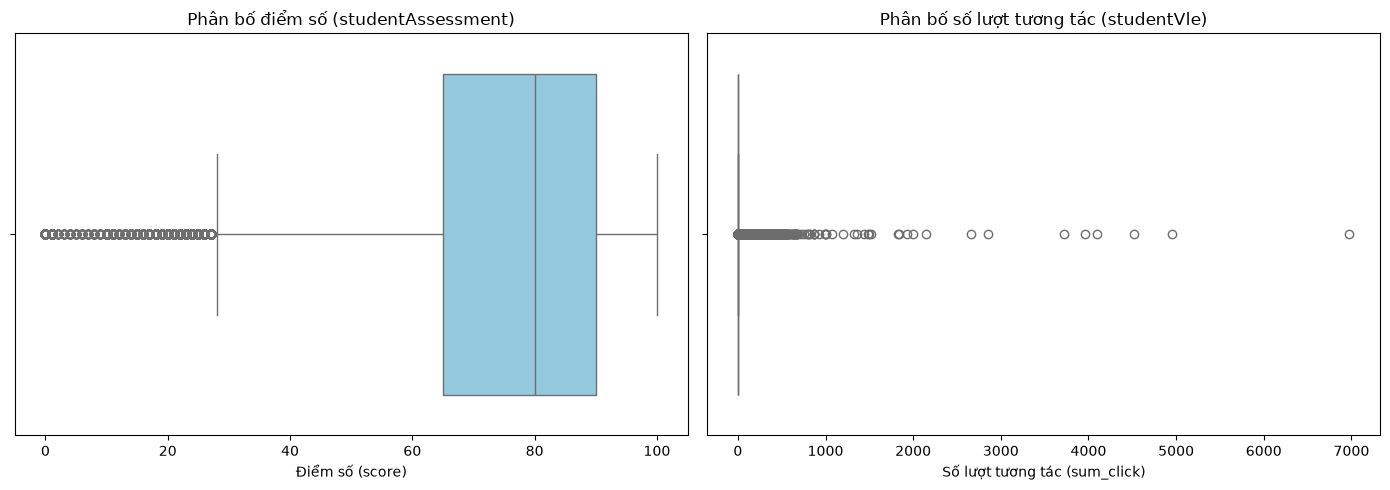

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot cho score
sns.boxplot(data=student_assessment, x='score', ax=axes[0], color='skyblue')
axes[0].set_title('Phân bố điểm số (studentAssessment)')
axes[0].set_xlabel('Điểm số (score)')

# Boxplot cho sum_click
sns.boxplot(data=student_vle, x='sum_click', ax=axes[1], color='salmon')
axes[1].set_title('Phân bố số lượt tương tác (studentVle)')
axes[1].set_xlabel('Số lượt tương tác (sum_click)')

plt.tight_layout()
plt.show()

### 4.3. Đánh giá & Nhận xét về Giá trị Bất thường (Outliers)

1. **Điểm số (`score`):**
   - Tất cả giá trị điểm số nằm trong khoảng hợp lệ $[0, 100]$. Không xuất hiện điểm âm hay điểm $>100$.
   - Các điểm 0 xuất hiện do sinh viên không đạt yêu cầu hoặc bỏ nộp bài, đây là giá trị thực tế hợp lý về mặt nghiệp vụ.

2. **Lượt tương tác trên hệ thống VLE (`sum_click`):**
   - Xuất hiện nhiều giá trị ngoại lệ (outliers) nằm phía bên phải boxplot (có những sinh viên tích lũy hàng nghìn lượt click).
   - **Đánh giá:** Đây là những sinh viên cực kỳ tích cực học tập trên hệ thống trực tuyến, không phải lỗi nhập liệu.
   - **Xử lý ở bước Preprocessing:** Giữ lại dữ liệu thực tế này, nhưng áp dụng phép biến đổi Logarit (`np.log1p`) để thu hẹp khoảng cách giá trị và chuẩn hóa phân bố cho mô hình ML.

## 5. Data Imbalance (Mất cân bằng dữ liệu)

### 5.1. Phân tích và phân bố mục tiêu

In [17]:
# Tính toán số lượng và tỷ lệ % chi tiết của từng lớp trong final_result
count_result = student_info['final_result'].value_counts()
percent_result = student_info['final_result'].value_counts(normalize=True) * 100

# Tổng hợp thành DataFrame
target_distribution = pd.DataFrame({
    'Số lượng sinh viên': count_result,
    'Tỷ lệ (%)': percent_result.round(2)
})

print("--- THỐNG KÊ PHÂN BỐ BẤT CÂN BẰNG CỦA BIẾN MỤC TIÊU (final_result) ---")
display(target_distribution)

--- THỐNG KÊ PHÂN BỐ BẤT CÂN BẰNG CỦA BIẾN MỤC TIÊU (final_result) ---


,Số lượng sinh viên,Tỷ lệ (%)
final_result,,
Pass,12361,37.93
Withdrawn,10156,31.16
Fail,7052,21.64
Distinction,3024,9.28


### 5.2 Trực quan hoá tỷ lệ các lớp dữ liệu

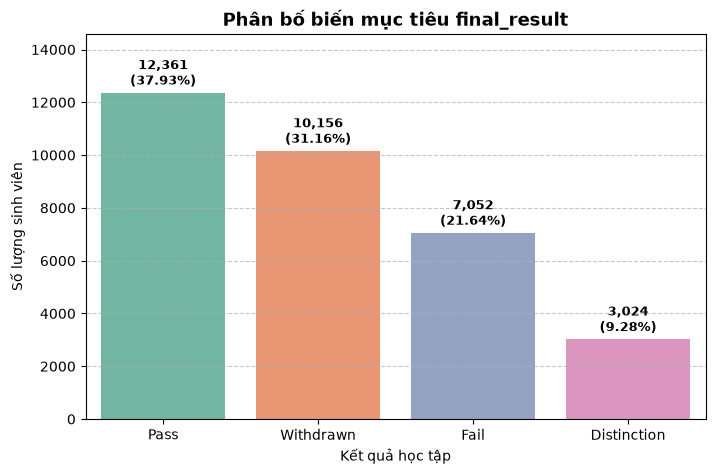

In [25]:
# Vẽ biểu đồ countplot minh họa tỷ lệ các lớp dữ liệu
plt.figure(figsize=(8, 5))

# Biểu đồ đếm số lượng từng lớp (Đã bổ sung hue và legend=False để loại bỏ cảnh báo)
ax = sns.countplot(
    data=student_info, 
    x='final_result', 
    hue='final_result',
    order=['Pass', 'Withdrawn', 'Fail', 'Distinction'], 
    palette='Set2',
    legend=False
)

plt.title('Phân bố kết quả học tập cuối kỳ (final_result)', fontsize=13, fontweight='bold')
plt.xlabel('Kết quả cuối kỳ (final_result)')
plt.ylabel('Số lượng sinh viên')

# Hiển thị phần trăm cụ thể trên đầu từng cột
total = len(student_info)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.2f}%'
    label = f'{int(height):,}\n({percentage})'
    
    x = p.get_x() + p.get_width() / 2
    y = height + 150  # Đẩy chữ lên trên đỉnh cột một chút
    ax.annotate(label, (x, y), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Phân bố biến mục tiêu final_result', fontsize=13, fontweight='bold')
plt.xlabel('Kết quả học tập')
plt.ylabel('Số lượng sinh viên')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(0, max(df_target_summary['Số lượng sinh viên']) * 1.18)
plt.show()

### 5.3. Đánh giá về Mất cân bằng Dữ liệu (Data Imbalance) & Tác động ML

| Nhóm kết quả (`final_result`) | Tỷ lệ (%) | Nhận xét phân bố |
| :--- | :---: | :--- |
| **Pass** (Đạt) | ~37% | Lớp chiếm tỷ lệ lớn nhất. |
| **Withdrawn** (Rút lui) | ~31% | Tỷ lệ sinh viên bỏ học/rút môn khá cao. |
| **Fail** (Trượt) | ~22% | Lớp thiểu số thứ 2. |
| **Distinction** (Xuất sắc) | ~9% | Lớp thiểu số nhất. |

> **Tác động đến Mô hình Machine Learning & Hướng giải quyết:**
> - **Hiện tượng:** Dữ liệu có sự mất cân bằng rõ rệt giữa lớp xuất sắc (`Distinction` ~9%) và các lớp khác.
> - **Nguy cơ:** Mô hình học máy dễ bị thiên vị (bias) sang lớp đa số (`Pass`/`Withdrawn`) và dễ đoán sai lớp thiểu số.
> - **Định hướng ở bước Preprocessing/Modeling:**
>   1. Gộp lớp nếu bài toán là Phân loại Nhị phân (Binary Classification): `Pass` + `Distinction` (Đạt) vs `Fail` + `Withdrawn` (Không đạt).
>   2. Sử dụng thang đo đánh giá phù hợp: Ưu tiên `Macro F1-Score`, `Precision-Recall AUC` thay vì chỉ dựa vào `Accuracy`.
>   3. Áp dụng kỹ thuật cân bằng lớp như `SMOTE` hoặc điều chỉnh `class_weight='balanced'` khi huấn luyện mô hình.

## 6. Tổng kết & Đánh giá tác động của Dữ liệu Thiếu / Lệch đến Mô hình Machine Learning

Phần này tổng hợp chi tiết các vấn đề về chất lượng dữ liệu (Data Quality Issues) đã phát hiện và phân tích ảnh hưởng trực tiếp của từng vấn đề đến mô hình Machine Learning nếu không được xử lý ở bước Preprocessing.

---

### 6.1. Bảng tổng hợp Dữ liệu Thiếu (Missing) và Dữ liệu Lệch (Imbalance/Outliers)

| Bảng dữ liệu | Cột dữ liệu | Tình trạng dữ liệu (Thiếu / Lệch) | Tỷ lệ / Mức độ |
| :--- | :--- | :--- | :--- |
| `studentRegistration` | `date_unregistration` | **Thiếu (Missing)** | **69.10%** (22,521 dòng) |
| `assessments` | `date` | **Thiếu (Missing)** | **5.34%** (11 dòng) |
| `studentInfo` | `imd_band` | **Thiếu (Missing)** | **3.41%** (1,111 dòng) |
| `studentRegistration` | `date_registration` | **Thiếu (Missing)** | **0.14%** (45 dòng) |
| `studentAssessment` | `score` | **Thiếu (Missing)** | **0.10%** (173 dòng) |
| `studentVle` | `sum_click` | **Lệch phải nặng (Right-skewed / Outliers)** | Phân bố lệch về bên phải, nhiều giá trị cực lớn (> 1,000) |
| `studentInfo` | `final_result` (Target) | **Mất cân bằng lớp (Class Imbalance)** | `Pass`: 37.93%, `Withdrawn`: 31.16%, `Fail`: 21.64%, `Distinction`: 9.28% |

---

### 6.2. Mức độ ảnh hưởng đến mô hình Machine Learning nếu KHÔNG xử lý

#### 1. Ảnh hưởng của Dữ liệu Khuyết thiếu (Missing Data):
- **Lỗi thực thi mô hình:** Hầu hết các thuật toán ML phổ biến như Logistic Regression, SVM, Neural Networks hay Random Forest (trong scikit-learn) không chấp nhận đầu vào chứa giá trị `NaN` và sẽ báo lỗi khi huấn luyện.
- **Sai lệch bản chất biến (Lỗi Logic):** 
  - Nếu xóa bỏ dòng thiếu `date_unregistration` (69.1%), mô hình sẽ bị mất đi toàn bộ dữ liệu của những sinh viên **hoàn thành khóa học**, dẫn đến thiên vị nặng nề về nhóm bỏ học.
  - Nếu xóa bỏ hoặc gán sai biến `score` (173 dòng) hay `date` trong `assessments`, mô hình sẽ tính toán sai tổng điểm trung bình và tốc độ học tập của sinh viên.
  - Thiếu `imd_band` làm mất đi thông tin yếu tố kinh tế - xã hội, giảm khả năng dự báo đối với các nhóm sinh viên yếu thế.

#### 2. Ảnh hưởng của Phân bố Lệch & Outliers (`sum_click`):
- **Gây nhiễu và méo sai lệch mô hình (Model Bias):** Thuộc tính `sum_click` bị lệch phải nghiêm trọng do một số sinh viên có lượt click rất cao.
- **Ảnh hưởng thuật toán dựa trên khoảng cách:** Các mô hình như KNN, SVM, Logistic Regression hay Gradient Descent rất nhạy cảm với thang đo. Các giá trị cực lớn sẽ áp đảo các đặc trưng khác, làm suy giảm độ chính xác của thuật toán.

#### 3. Ảnh hưởng của Mất cân bằng lớp biến mục tiêu (`final_result`):
- **Hiện tượng Bẫy Độ chính xác (Accuracy Paradox):** Mô hình sẽ bị thiên vị (bias) dự đoán vào các lớp chiếm đa số (`Pass` ~37.9% và `Withdrawn` ~31.2%) để tối ưu hóa Accuracy toàn cục, nhưng sẽ **dự đoán rất kém hoặc bỏ sót hoàn toàn lớp thiểu số** như `Distinction` (chỉ chiếm 9.28%) hoặc `Fail`.
- **Hệ quả thực tế:** Hệ thống dự báo sẽ không phát hiện kịp thời những sinh viên có nguy cơ trượt môn (`Fail`) hoặc những sinh viên xuất sắc (`Distinction`), làm mất đi ý nghĩa ứng dụng của bài toán Learning Analytics.

---

### 6.3. Đề xuất chiến lược xử lý cho bước Preprocessing tiếp theo
1. **Xử lý Missing Data:**
   - `date_unregistration`: Giữ nguyên `NaN` hoặc tạo thêm biến nhãn nhị phân `is_unregistered` ($1$ nếu hủy đăng ký, $0$ nếu không).
   - `score`: Điền bằng `0` (coi như bỏ thi/không nộp bài).
   - `imd_band`: Điền bằng `Mode` hoặc nhãn `'Unknown'`.
   - `date`: Điền bằng giá trị `Median` của bài thi tương ứng.
2. **Xử lý Outliers / Lệch dữ liệu:**
   - Áp dụng biến đổi Logarit: `np.log1p(sum_click)` để thu hẹp khoảng giá trị và đưa phân bố về dạng tiệm cận chuẩn (Normal Distribution).
3. **Xử lý Mất cân bằng lớp (Data Imbalance):**
   - Chuyển đổi bài toán sang Phân loại nhị phân (`Pass/Distinction` vs `Fail/Withdrawn`) hoặc sử dụng kỹ thuật `SMOTE` / `class_weight='balanced'`.
   - Thay thế độ đo đánh giá `Accuracy` bằng `Macro F1-Score` và `Balanced Accuracy`.